# **Exploratory Data Analysis on Retail Sales**

**Import Libraries**

In [1]:
import pandas as pd
import numpy as np
import plotly.express as px
import seaborn as sns
import matplotlib.pyplot as plt

**Data Loading**

In [6]:
df = pd.read_csv("retail_sales_dataset.csv")

print("First 5 Rows:")
print(df.head())


First 5 Rows:
   Transaction ID        Date Customer ID  Gender  Age Product Category  \
0               1  2023-11-24     CUST001    Male   34           Beauty   
1               2  2023-02-27     CUST002  Female   26         Clothing   
2               3  2023-01-13     CUST003    Male   50      Electronics   
3               4  2023-05-21     CUST004    Male   37         Clothing   
4               5  2023-05-06     CUST005    Male   30           Beauty   

   Quantity  Price per Unit  Total Amount  
0         3              50           150  
1         2             500          1000  
2         1              30            30  
3         1             500           500  
4         2              50           100  


**Data Cleaning**

In [7]:
# Convert Date column to datetime
df['Date'] = pd.to_datetime(df['Date'])

# Check missing values
print("\nMissing Values:")
print(df.isnull().sum())


Missing Values:
Transaction ID      0
Date                0
Customer ID         0
Gender              0
Age                 0
Product Category    0
Quantity            0
Price per Unit      0
Total Amount        0
dtype: int64


**Descriptive Statistics**

In [8]:
print("\nDescriptive Statistics:")
print(df.describe())

print("\nMean:")
print(df.mean(numeric_only=True))

print("\nMedian:")
print(df.median(numeric_only=True))

print("\nMode:")
print(df.mode().iloc[0])

print("\nStandard Deviation:")
print(df.std(numeric_only=True))


Descriptive Statistics:
       Transaction ID                           Date         Age     Quantity  \
count     1000.000000                           1000  1000.00000  1000.000000   
mean       500.500000  2023-07-03 00:25:55.200000256    41.39200     2.514000   
min          1.000000            2023-01-01 00:00:00    18.00000     1.000000   
25%        250.750000            2023-04-08 00:00:00    29.00000     1.000000   
50%        500.500000            2023-06-29 12:00:00    42.00000     3.000000   
75%        750.250000            2023-10-04 00:00:00    53.00000     4.000000   
max       1000.000000            2024-01-01 00:00:00    64.00000     4.000000   
std        288.819436                            NaN    13.68143     1.132734   

       Price per Unit  Total Amount  
count     1000.000000   1000.000000  
mean       179.890000    456.000000  
min         25.000000     25.000000  
25%         30.000000     60.000000  
50%         50.000000    135.000000  
75%        300.00

**Time Series Analysis**

In [9]:

# Monthly Sales Trend
df['Month'] = df['Date'].dt.to_period('M').astype(str)

monthly_sales = df.groupby('Month')['Total Amount'].sum().reset_index()

fig1 = px.line(
    monthly_sales,
    x='Month',
    y='Total Amount',
    title='Monthly Sales Trend'
)
fig1.show()


**Product Analysis**

In [11]:
fig2 = px.bar(
    category_sales,
    x='Product Category',
    y='Total Amount',
    title='Sales by Product Category',
    color='Product Category',
    color_discrete_sequence=['#1B2631', '#5DADE2', '#AED6F1']
)

fig2.update_layout(
    plot_bgcolor='white',
    paper_bgcolor='white',
    font=dict(color='#1B2631'),
    title_x=0.5
)

fig2.show()

**Customer Analysis**

In [20]:
# Group data by Gender
gender_sales = df.groupby('Gender')['Total Amount'].sum().reset_index()
fig3 = px.pie(
    gender_sales,
    names='Gender',
    values='Total Amount',
    title='Sales by Gender',
    color_discrete_sequence=['#5DADE2', '#1B2631']  # light blue & navy
)

fig3.update_layout(
    title_x=0.5,
    paper_bgcolor='white'
)

fig3.show()

**Heatmap (Correlation)**

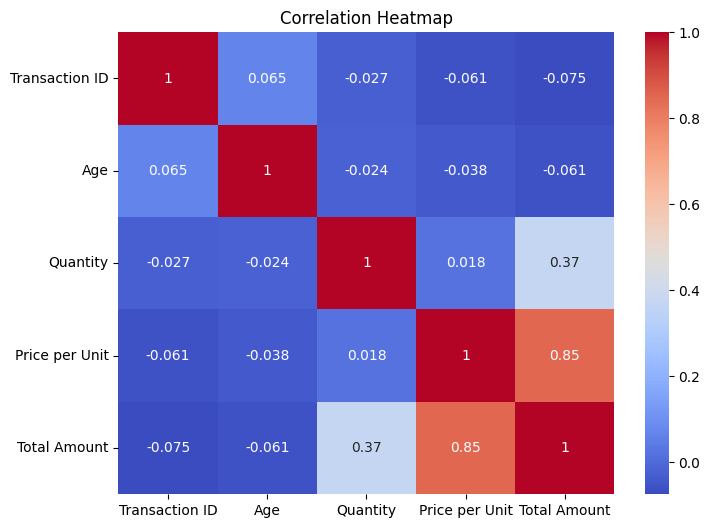

In [22]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

**Customer Age Distribution**

In [29]:
fig = px.histogram(
    df,
    x='Age',
    nbins=10,
    marginal='rug',   # adds distribution marks
    title='Age Distribution with Density'
)

fig.update_traces(
    marker=dict(color='#5DADE2', line=dict(width=1, color='#1B2631'))
)

fig.update_layout(
    plot_bgcolor='white',
    paper_bgcolor='white',
    title_x=0.5
)

fig.show()

**Age vs Spending (SCATTER PLOT)**

In [18]:
fig5 = px.scatter(
    df,
    x='Age',
    y='Total Amount',
    title='Age vs Spending',
    color_discrete_sequence=['#1B2631']
)

fig5.update_traces(
    marker=dict(
        size=10,
        color='#5DADE2',   # Light Blue
        line=dict(width=0) # ❌ Removes border completely
    )
)

fig5.update_layout(
    plot_bgcolor='white',
    paper_bgcolor='white',
    font=dict(color='#1B2631'),
    title_x=0.5
)

fig5.show()

**Top Customers**

In [30]:
top_customers = df.groupby('Customer ID')['Total Amount'].sum().sort_values(ascending=False).head(5)

print("\nTop 5 Customers:")
print(top_customers)


Top 5 Customers:
Customer ID
CUST015    2000
CUST412    2000
CUST970    2000
CUST547    2000
CUST281    2000
Name: Total Amount, dtype: int64


**Recommendations**

In [31]:
print("\nRecommendations:")
print("1. Focus marketing on high-value customers.")
print("2. Increase stock for top-selling categories.")
print("3. Offer discounts during low-sales periods.")
print("4. Target middle-aged customers with promotions.")
print("5. Use seasonal trends for business planning.")


Recommendations:
1. Focus marketing on high-value customers.
2. Increase stock for top-selling categories.
3. Offer discounts during low-sales periods.
4. Target middle-aged customers with promotions.
5. Use seasonal trends for business planning.
